# EDA simple de la consommation électrique

Objectif : charger le CSV RTE, comprendre rapidement sa qualité, construire une série de consommation nationale et préparer un fichier propre pour la modélisation.

On suit une démarche simple : **voir les premières lignes -> contrôler les nulls et les types -> vérifier le temps -> analyser la cible -> préparer les lags**.

La modélisation viendra ensuite avec un découpage temporel strict, sans `shuffle=True`.

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/eco2mix-regional-cons-def.csv')
OUTPUT_PATH = Path('../data/eco2mix.csv')

# Le fichier utilise le séparateur ';' et contient 'ND' pour les données inconnues.
df = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values=['ND', 'nd', '', ' '],
    low_memory=False,
    encoding='utf-8'
)

print('Dimensions :', df.shape)
display(df.head())

Dimensions : (2839104, 32)


,Code INSEE région,Région,Nature,Date,Heure,Date - Heure,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),Solaire (MW),Hydraulique (MW),Pompage (MW),Bioénergies (MW),Ech. physiques (MW),Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore,TCO Thermique (%),TCH Thermique (%),TCO Nucléaire (%),TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Column 30
0,53,Bretagne,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,76,Occitanie,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,44,Grand Est,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28,Normandie,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,Île-de-France,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Comprendre rapidement les données

Le `head()` montre que le fichier est régional : plusieurs régions existent pour un même timestamp. Les colonnes de production ne seront pas conservées pour la modélisation, car elles peuvent provoquer une fuite de données. Nous allons d'abord contrôler les colonnes utiles et les valeurs manquantes.

In [5]:
print('Types des colonnes utiles :')
print(df[['Région', 'Date - Heure', 'Consommation (MW)']].dtypes)

print('\nValeurs nulles :')
nulls = df.isna().sum().sort_values(ascending=False)
display(nulls[nulls > 0].to_frame('nombre_nulls').head(10))

print('Doublons exacts :', df.duplicated().sum())
print('Régions :', df['Région'].nunique())
print(df['Région'].value_counts().head())

Types des colonnes utiles :
Région                object
Date - Heure          object
Consommation (MW)    float64
dtype: object

Valeurs nulles :


,nombre_nulls
Column 30,2839104
TCH Nucléaire (%),2041776
Stockage batterie,1683084
Eolien offshore,1683084
Eolien terrestre,1683084
Déstockage batterie,1683084
TCO Nucléaire (%),1560097
TCO Thermique (%),1472257
TCO Bioénergies (%),1472257
TCO Hydraulique (%),1472257


Doublons exacts : 0
Régions : 12
Région
Bretagne         236592
Occitanie        236592
Grand Est        236592
Normandie        236592
Île-de-France    236592
Name: count, dtype: int64


**Analyse :** les `ND` sont normaux dans certaines colonnes, mais la cible doit être suffisamment renseignée. Si les nulls de consommation sont rares, nous pourrons supprimer ces lignes avant l'entraînement. Nous ne remplirons pas automatiquement une longue période manquante, car cela fabriquerait de fausses observations.

In [6]:
df['Date - Heure'] = pd.to_datetime(df['Date - Heure'], errors='coerce', utc=True)
df['Consommation (MW)'] = pd.to_numeric(df['Consommation (MW)'], errors='coerce')

df = df.dropna(subset=['Date - Heure']).copy()

# Une ligne par région et demi-heure : on additionne les régions.
conso = (
    df.groupby('Date - Heure', as_index=False)['Consommation (MW)']
      .sum(min_count=1)
      .rename(columns={
          'Date - Heure': 'timestamp',
          'Consommation (MW)': 'consommation_mw'
      })
      .sort_values('timestamp')
      .reset_index(drop=True)
)

print('Série nationale :')
print(conso.shape)
display(conso.head())

Série nationale :
(236564, 2)


,timestamp,consommation_mw
0,2012-12-31 23:00:00+00:00,NaN
1,2012-12-31 23:30:00+00:00,"59,662.00"
2,2013-01-01 00:00:00+00:00,"57,866.00"
3,2013-01-01 00:30:00+00:00,"57,747.00"
4,2013-01-01 01:00:00+00:00,"57,234.00"


## 2. Vérifier la fréquence temporelle

La donnée est annoncée en demi-heure. Cette vérification est indispensable avant de créer `lag_48` pour 24 heures et `lag_336` pour 7 jours.

In [8]:
pas = conso['timestamp'].diff().value_counts()
print('Pas les plus fréquents :')
display(pas.head())

print('Début :', conso['timestamp'].min())
print('Fin :', conso['timestamp'].max())
print('Timestamps dupliqués :', conso['timestamp'].duplicated().sum())

Pas les plus fréquents :


timestamp
0 days 00:30:00    236550
0 days 01:30:00        13
Name: count, dtype: int64

Début : 2012-12-31 23:00:00+00:00
Fin : 2026-06-30 21:30:00+00:00
Timestamps dupliqués : 0


## 3. Analyse des distributions et des régions

Les régions ne doivent pas être supprimées si l'objectif devient une prévision locale. Nous avons seulement agrégé les régions dans `conso` pour construire une cible **France entière**.

Deux stratégies sont possibles :

- **prévision nationale** : une ligne par timestamp, obtenue par somme des régions ;
- **prévision régionale** : une ligne par couple `Région` / `timestamp`, avec un modèle par région ou un modèle global utilisant la région comme variable.

Nous allons donc analyser la distribution de la consommation et les différences entre régions avant de choisir la stratégie.

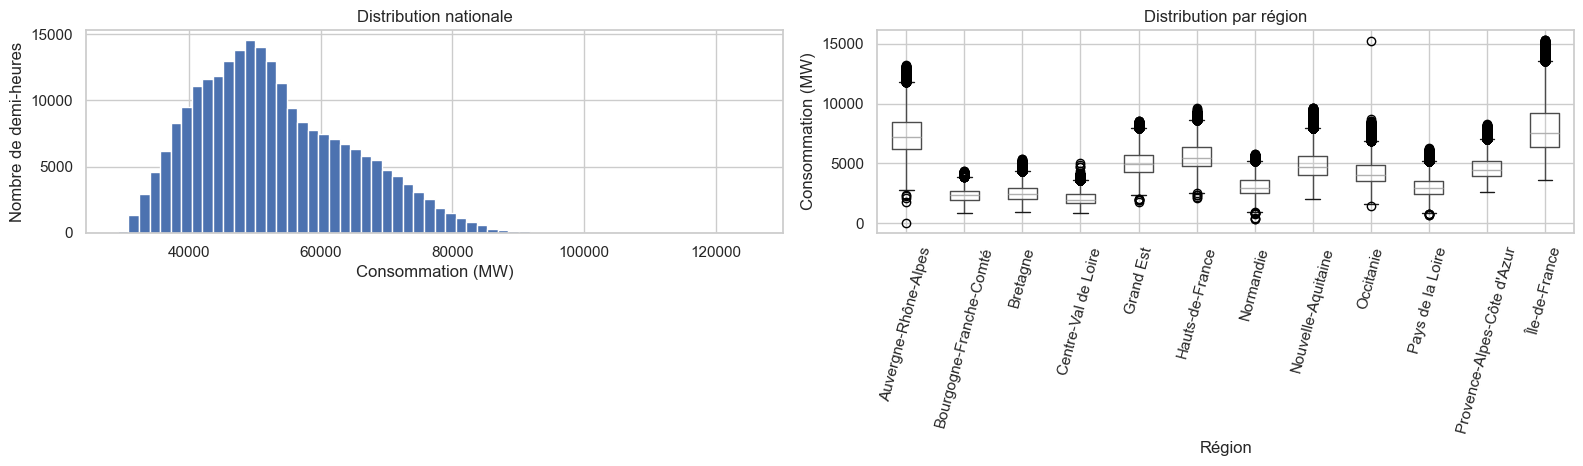

Nombre de régions analysées : 12


,count,mean,min,max
Région,,,,
Île-de-France,236591,"7,867.00","3,641.00","15,338.00"
Auvergne-Rhône-Alpes,236591,"7,389.00",0.00,"13,177.00"
Hauts-de-France,236591,"5,626.00","2,133.00","9,598.00"
Grand Est,236591,"5,072.00","1,760.00","8,568.00"
Nouvelle-Aquitaine,236591,"4,872.00","2,055.00","9,663.00"
Provence-Alpes-Côte d'Azur,236591,"4,597.00","2,620.00","8,331.00"
Occitanie,236591,"4,237.00","1,414.00","15,216.00"
Normandie,236591,"3,117.00",383.00,"5,759.00"
Pays de la Loire,236591,"3,036.00",703.00,"6,265.00"


In [15]:
# Distribution nationale et comparaison entre régions.
regional = (
    df[['Région', 'Date - Heure', 'Consommation (MW)']]
      .dropna(subset=['Région', 'Date - Heure', 'Consommation (MW)'])
      .rename(columns={
          'Date - Heure': 'timestamp',
          'Consommation (MW)': 'consommation_mw'
      })
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(conso['consommation_mw'].dropna(), bins=60, edgecolor='white')
axes[0].set_title('Distribution nationale')
axes[0].set_xlabel('Consommation (MW)')
axes[0].set_ylabel('Nombre de demi-heures')

regional.boxplot(column='consommation_mw', by='Région', ax=axes[1], rot=75)
axes[1].set_title('Distribution par région')
axes[1].set_xlabel('Région')
axes[1].set_ylabel('Consommation (MW)')
fig.suptitle('')
plt.tight_layout()
plt.show()

print('Nombre de régions analysées :', regional['Région'].nunique())
display(
    regional.groupby('Région')['consommation_mw']
            .agg(['count', 'mean', 'min', 'max'])
            .sort_values('mean', ascending=False)
            .round(0)
)

## 4. Consommation mensuelle pour chaque année

Ce graphique permet de voir si la saisonnalité est stable. Une forme similaire chaque année justifie l'utilisation de `month` et des lags hebdomadaires. Une année très différente doit être conservée dans le test temporel pour vérifier la généralisation du modèle.

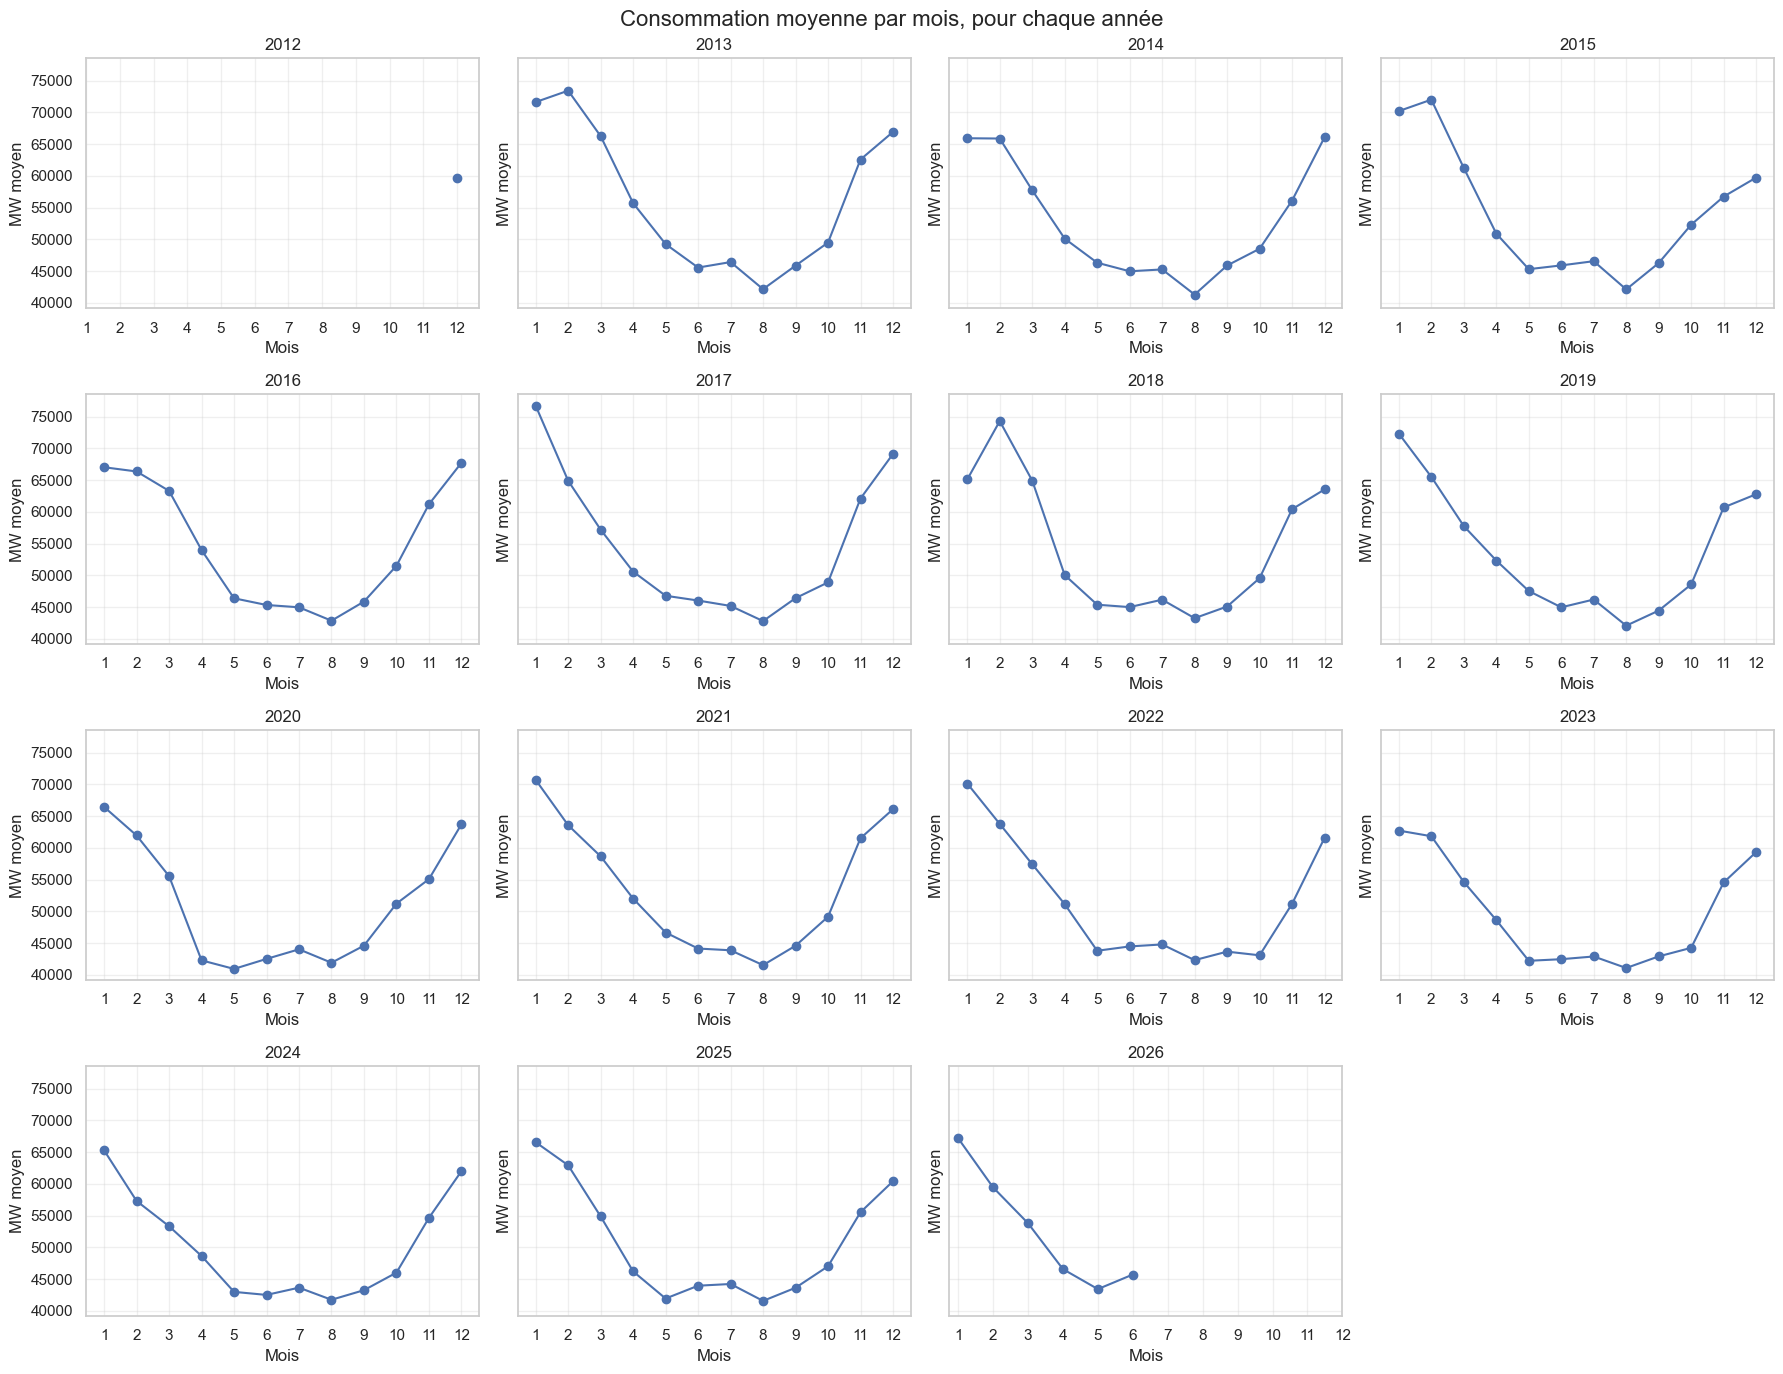

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
month,,,,,,,,,,,,,,,
1,NaN,"71,629.00","65,930.00","70,208.00","67,029.00","76,708.00","65,111.00","72,321.00","66,441.00","70,705.00","70,133.00","62,720.00","65,271.00","66,550.00","67,178.00"
2,NaN,"73,422.00","65,887.00","72,007.00","66,364.00","64,898.00","74,297.00","65,516.00","61,951.00","63,566.00","63,769.00","61,835.00","57,303.00","62,923.00","59,445.00"
3,NaN,"66,261.00","57,739.00","61,251.00","63,307.00","57,203.00","64,923.00","57,769.00","55,552.00","58,665.00","57,425.00","54,630.00","53,327.00","54,867.00","53,803.00"
4,NaN,"55,711.00","50,127.00","50,923.00","53,997.00","50,598.00","50,053.00","52,345.00","42,292.00","52,016.00","51,139.00","48,630.00","48,645.00","46,216.00","46,575.00"
5,NaN,"49,270.00","46,335.00","45,322.00","46,401.00","46,800.00","45,390.00","47,546.00","40,946.00","46,677.00","43,804.00","42,224.00","42,996.00","41,947.00","43,432.00"
6,NaN,"45,573.00","44,989.00","45,915.00","45,346.00","46,047.00","45,012.00","44,981.00","42,522.00","44,152.00","44,487.00","42,476.00","42,516.00","43,965.00","45,725.00"
7,NaN,"46,438.00","45,279.00","46,577.00","44,983.00","45,197.00","46,182.00","46,206.00","44,031.00","43,880.00","44,798.00","42,905.00","43,659.00","44,236.00",NaN
8,NaN,"42,173.00","41,322.00","42,136.00","42,873.00","42,814.00","43,270.00","42,089.00","41,917.00","41,540.00","42,328.00","41,087.00","41,753.00","41,575.00",NaN
9,NaN,"45,878.00","45,899.00","46,282.00","45,879.00","46,424.00","45,105.00","44,463.00","44,609.00","44,595.00","43,667.00","42,917.00","43,261.00","43,642.00",NaN


In [16]:
monthly = conso.assign(
    year=conso['timestamp'].dt.year,
    month=conso['timestamp'].dt.month
).groupby(['year', 'month'])['consommation_mw'].mean().reset_index()

years = sorted(monthly['year'].unique())
columns = 4
rows = int(np.ceil(len(years) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(18, 3.5 * rows), sharey=True)
axes = np.asarray(axes).reshape(-1)

for index, year in enumerate(years):
    year_data = monthly[monthly['year'] == year].set_index('month')
    values = year_data['consommation_mw'].reindex(range(1, 13))
    axes[index].plot(range(1, 13), values, marker='o')
    axes[index].set_title(str(year))
    axes[index].set_xticks(range(1, 13))
    axes[index].set_xlabel('Mois')
    axes[index].set_ylabel('MW moyen')
    axes[index].grid(True, alpha=0.3)

for axis in axes[len(years):]:
    axis.set_visible(False)

fig.suptitle('Consommation moyenne par mois, pour chaque année', fontsize=16)
plt.tight_layout()
plt.show()

display(monthly.pivot(index='month', columns='year', values='consommation_mw').round(0))

## 5. Choix de la cible : nationale ou régionale

Les données régionales sont conservées. Pour commencer, nous gardons deux fichiers :

- `eco2mix.csv` : cible France entière, utile pour la première baseline ;
- `eco2mix_regional.csv` : cible par région, utile pour entraîner un modèle régional.

Une prévision régionale est possible et peut être plus utile opérationnellement. Il faudra simplement créer les lags **à l'intérieur de chaque région** avec `groupby('Région')`, puis évaluer les performances région par région. Un modèle global avec la région comme variable peut aussi apprendre les comportements communs tout en conservant les différences de niveau.

In [17]:
regional_clean = regional[['Région', 'timestamp', 'consommation_mw']].copy()
regional_clean = (
    regional_clean.drop_duplicates(['Région', 'timestamp'])
                  .sort_values(['Région', 'timestamp'])
                  .reset_index(drop=True)
)

regional_output = Path('../data/eco2mix_regional.csv')
regional_clean.to_csv(regional_output, index=False)

print('Fichier régional sauvegardé :', regional_output)
print('Dimensions :', regional_clean.shape)
display(regional_clean.head())

Fichier régional sauvegardé : ..\data\eco2mix_regional.csv
Dimensions : (2838756, 3)


,Région,timestamp,consommation_mw
0,Auvergne-Rhône-Alpes,2012-12-31 23:30:00+00:00,"8,173.00"
1,Auvergne-Rhône-Alpes,2013-01-01 00:00:00+00:00,"7,944.00"
2,Auvergne-Rhône-Alpes,2013-01-01 00:30:00+00:00,"7,896.00"
3,Auvergne-Rhône-Alpes,2013-01-01 01:00:00+00:00,"7,882.00"
4,Auvergne-Rhône-Alpes,2013-01-01 01:30:00+00:00,"7,909.00"


## 4. Variables calendaires et lags

Ces variables sont calculées uniquement à partir du timestamp et de l'historique de consommation. Elles sont donc compatibles avec une prévision day-ahead. `lag_48` représente la consommation observée 24 heures plus tôt et `lag_336` celle observée une semaine plus tôt.

In [14]:
# On remet la série sur une grille régulière de 30 minutes.
# Les timestamps absents restent NaN : ils ne sont pas inventés.
conso = (
    conso.set_index('timestamp')
         .asfreq('30min')
         .rename_axis('timestamp')
         .reset_index()
)

conso['hour'] = conso['timestamp'].dt.hour
conso['dayofweek'] = conso['timestamp'].dt.dayofweek
conso['month'] = conso['timestamp'].dt.month

# Ces décalages représentent maintenant exactement le passé à 30 minutes.
conso['lag_1'] = conso['consommation_mw'].shift(1)
conso['lag_48'] = conso['consommation_mw'].shift(48)
conso['lag_336'] = conso['consommation_mw'].shift(336)

print('Valeurs manquantes après remise sur grille :')
display(conso[['consommation_mw', 'lag_1', 'lag_48', 'lag_336']].isna().sum().to_frame('nombre_nulls'))
print('Corrélations simples des lags avec la cible :')
display(conso[['consommation_mw', 'lag_1', 'lag_48', 'lag_336']].corr()['consommation_mw'].to_frame())

Valeurs manquantes après remise sur grille :


,nombre_nulls
consommation_mw,26
lag_1,27
lag_48,74
lag_336,362


Corrélations simples des lags avec la cible :


,consommation_mw
consommation_mw,1.00
lag_1,0.99
lag_48,0.93
lag_336,0.90


## 5. Préparation finale

Pour éviter la fuite de données, le fichier de base sauvegardé ne contient que le timestamp et la consommation. Les variables calendaires et les lags seront recréés dans le pipeline d'entraînement, puis le découpage train/test sera fait dans l'ordre du temps. Les premières lignes sans historique complet seront supprimées après création des lags.

In [13]:
clean = conso[['timestamp', 'consommation_mw']].copy()
clean = clean.dropna().drop_duplicates('timestamp').sort_values('timestamp')

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(OUTPUT_PATH, index=False)

print('Fichier sauvegardé :', OUTPUT_PATH)
print('Dimensions finales :', clean.shape)
display(clean.head())

Fichier sauvegardé : ..\data\eco2mix.csv
Dimensions finales : (236563, 2)


,timestamp,consommation_mw
0,2012-12-31 23:30:00+00:00,"59,662.00"
1,2013-01-01 00:00:00+00:00,"57,866.00"
2,2013-01-01 00:30:00+00:00,"57,747.00"
3,2013-01-01 01:00:00+00:00,"57,234.00"
4,2013-01-01 01:30:00+00:00,"56,649.00"


## Conclusion

La région n'est pas supprimée : elle est maintenant analysée et exportée séparément. La décision de départ est de tester d'abord la baseline nationale, puis de comparer une prévision régionale.

Résultats observés :

- les niveaux de consommation sont très différents selon les régions ;
- les distributions régionales sont asymétriques et contiennent des pics ;
- la consommation baisse généralement au printemps et en été, puis augmente en automne et en hiver ;
- les années 2020 à 2022 se distinguent, ce qui justifie un test temporel récent ;
- les lags `48` et `336` restent cohérents pour une série régulière de 30 minutes.

La prochaine étape sera de créer les features et les lags par région, sans mélange entre régions, puis d'évaluer séparément les modèles national et régional.